In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/Owner/Desktop/Jupyter/Learning/World-happiness-report-updated_2024.csv', encoding='latin-1')
print(df.head())

  Country name  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.350           0.451   
1  Afghanistan  2009        4.402               7.509           0.552   
2  Afghanistan  2010        4.758               7.614           0.539   
3  Afghanistan  2011        3.832               7.581           0.521   
4  Afghanistan  2012        3.783               7.661           0.521   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                              50.5                         0.718       0.164   
1                              50.8                         0.679       0.187   
2                              51.1                         0.600       0.118   
3                              51.4                         0.496       0.160   
4                              51.7                         0.531       0.234   

   Perceptions of corruption  Positive affect  Negative affect  
0        

In [9]:
print(df.shape)
print(df.info())
print(df.describe())

(2363, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   str    
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 203.2 KB
None
         

In [10]:
print(df.isnull().sum())

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   28
Social support                       13
Healthy life expectancy at birth     63
Freedom to make life choices         36
Generosity                           81
Perceptions of corruption           125
Positive affect                      24
Negative affect                      16
dtype: int64


In [11]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(df.isnull().sum())

Country name                        0
year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
dtype: int64


In [12]:
df = df.rename(columns = {
    'Life Ladder': 'happiness',
    'Log GDP per capita': 'gdp',
    'Social support': 'social_support',
    'Healthy life expectancy at birth': 'life_expectancy',
    'Freedom to make life choices': 'freedom',
    'Perceptions of corruption': 'corruption',
    'Positive affect': 'positive_affect',
    'Negative affect': 'negative_affect',
    'Country name': 'country'
    
})

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2363 non-null   str    
 1   year             2363 non-null   int64  
 2   happiness        2363 non-null   float64
 3   gdp              2363 non-null   float64
 4   social_support   2363 non-null   float64
 5   life_expectancy  2363 non-null   float64
 6   freedom          2363 non-null   float64
 7   Generosity       2363 non-null   float64
 8   corruption       2363 non-null   float64
 9   positive_affect  2363 non-null   float64
 10  negative_affect  2363 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 203.2 KB
None


In [14]:
print(df.columns)

Index(['country', 'year', 'happiness', 'gdp', 'social_support',
       'life_expectancy', 'freedom', 'Generosity', 'corruption',
       'positive_affect', 'negative_affect'],
      dtype='str')


In [15]:
df = df.rename(columns = {
    'Generosity': 'generosity'
})

print(df.columns)

Index(['country', 'year', 'happiness', 'gdp', 'social_support',
       'life_expectancy', 'freedom', 'generosity', 'corruption',
       'positive_affect', 'negative_affect'],
      dtype='str')


In [16]:
# GDP per happiness point — how much wealth does it take to buy 1 happiness point?
df['gdp_per_happiness'] = df['gdp'] / df['happiness']

# Net affect — positive emotions minus negative emotions
df['net_affect'] = df['positive_affect'] - df['negative_affect']

print(df[['country', 'year', 'gdp_per_happiness', 'net_affect']].head())

       country  year  gdp_per_happiness  net_affect
0  Afghanistan  2008           1.973684       0.156
1  Afghanistan  2009           1.705816       0.244
2  Afghanistan  2010           1.600252       0.242
3  Afghanistan  2011           1.978340       0.213
4  Afghanistan  2012           2.025112       0.346


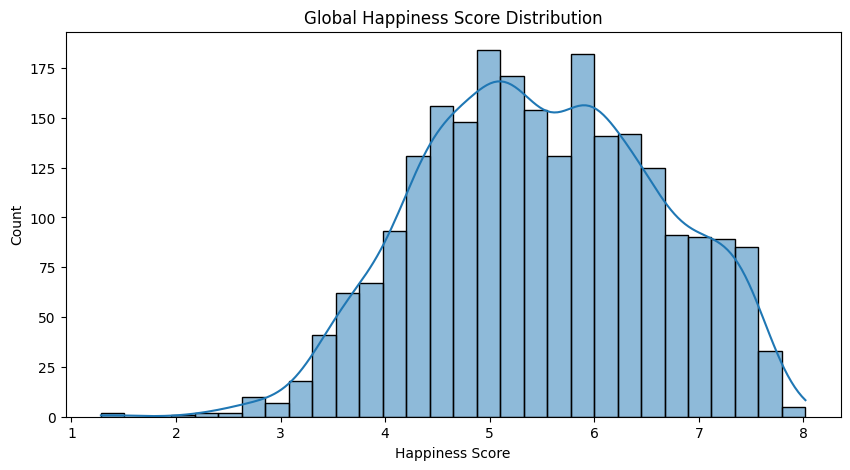

In [18]:
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(df['happiness'], bins = 30, kde= True, ax = ax)
ax.set_title('Global Happiness Score Distribution')
ax.set_xlabel('Happiness Score')
ax.set_ylabel('Count')
plt.show()

In [20]:
df_2023 = df[df['year'] == 2023]
top10 = df_2023.nlargest(10, 'happiness')
bottom10 = df_2023.nsmallest(10, 'happiness')

print(top10[['country', 'happiness']])
print(bottom10[['country', 'happiness']])

          country  happiness
680       Finland      7.699
886       Iceland      7.562
556       Denmark      7.504
490    Costa Rica      7.384
1498  Netherlands      7.255
1594       Norway      7.249
2004       Sweden      7.161
1129       Kuwait      7.130
97      Australia      7.025
1249   Luxembourg      7.016
               country  happiness
14         Afghanistan      1.446
1277            Malawi      3.272
258           Botswana      3.332
472   Congo (Kinshasa)      3.383
1835      Sierra Leone      3.467
2327             Yemen      3.532
2362          Zimbabwe      3.572
448            Comoros      3.588
1194           Lebanon      3.588
1964         Sri Lanka      3.602


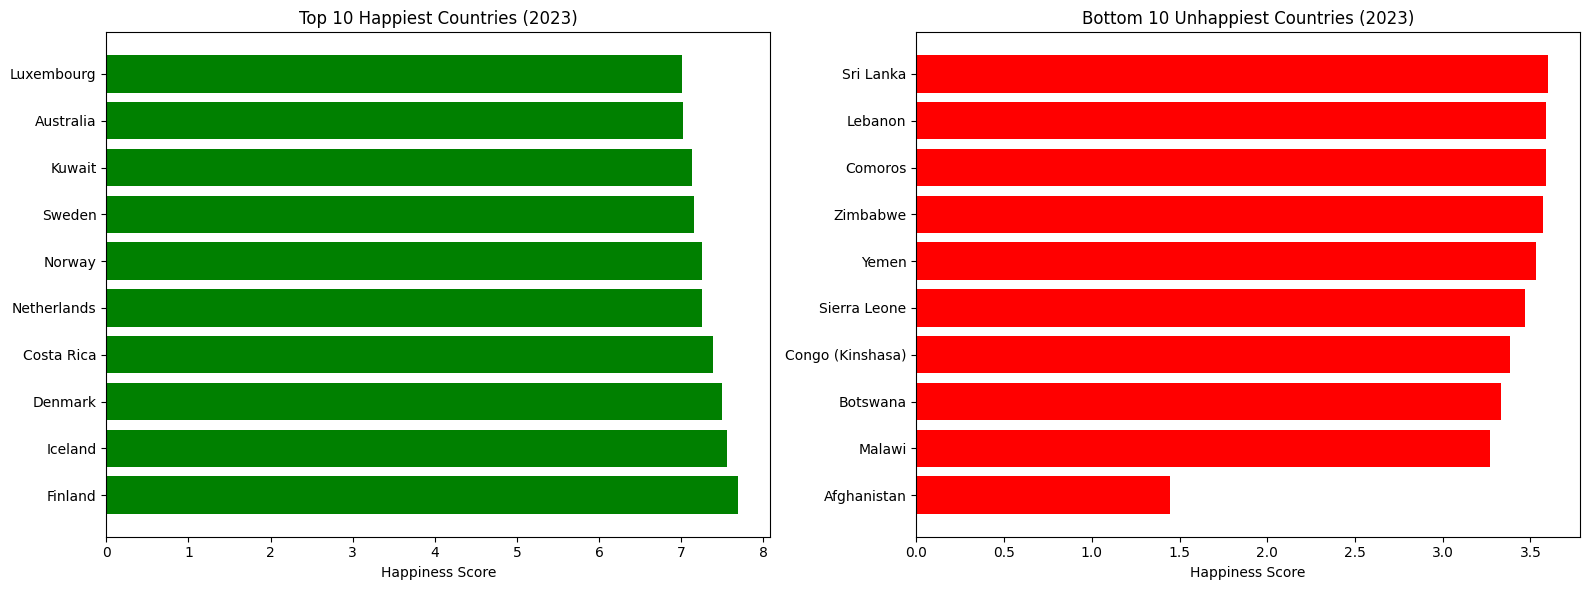

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].barh(top10['country'], top10['happiness'], color='green')
axes[0].set_title('Top 10 Happiest Countries (2023)')
axes[0].set_xlabel('Happiness Score')

axes[1].barh(bottom10['country'], bottom10['happiness'], color='red')
axes[1].set_title('Bottom 10 Unhappiest Countries (2023)')
axes[1].set_xlabel('Happiness Score')

plt.tight_layout()
plt.show()

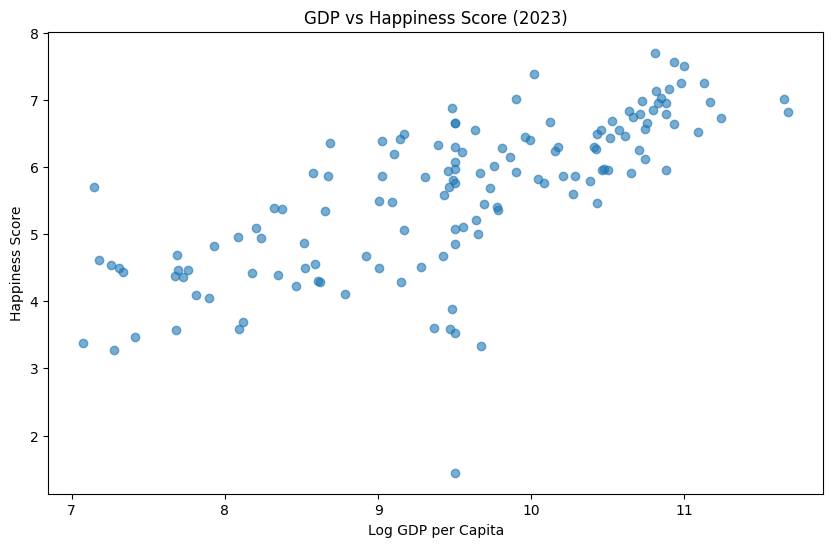

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_2023['gdp'], df_2023['happiness'], alpha=0.6)

ax.set_title('GDP vs Happiness Score (2023)')
ax.set_xlabel('Log GDP per Capita')
ax.set_ylabel('Happiness Score')

plt.show()

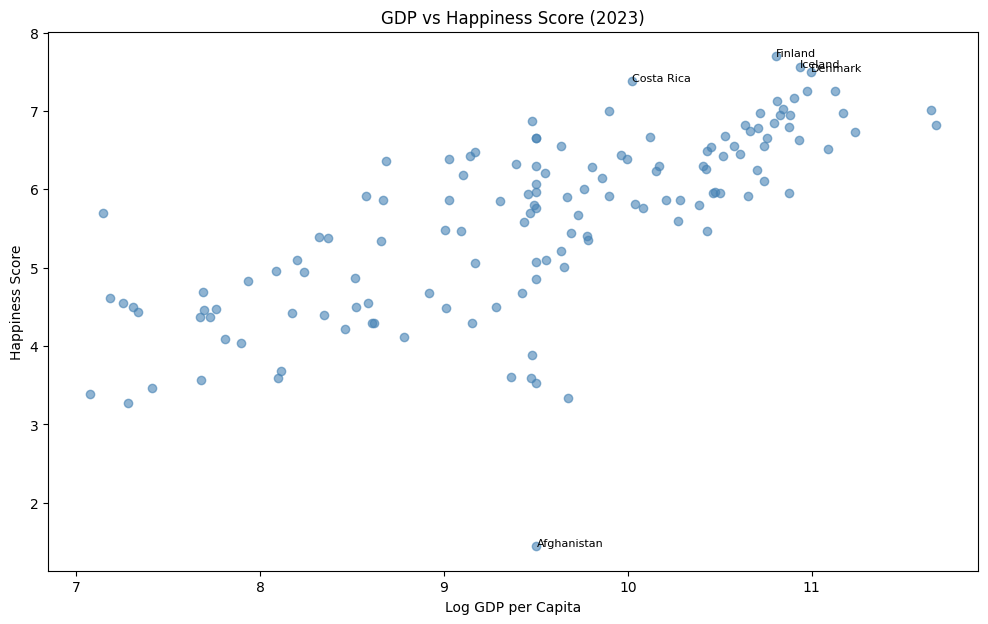

In [26]:
fig, ax = plt.subplots( figsize = (12, 7))

ax.scatter(df_2023['gdp'], df_2023['happiness'], alpha = 0.6, color = 'steelblue')

for _, row in df_2023.iterrows():
    if row['happiness'] > 7.3 or row['happiness'] < 2 or \
       (row['gdp'] > 10.5 and row['happiness'] < 5):
        ax.annotate(row['country'], 
                   (row['gdp'], row['happiness']),
                   fontsize=8, ha='left')

ax.set_title('GDP vs Happiness Score (2023)')
ax.set_xlabel('Log GDP per Capita')
ax.set_ylabel('Happiness Score')

plt.show()

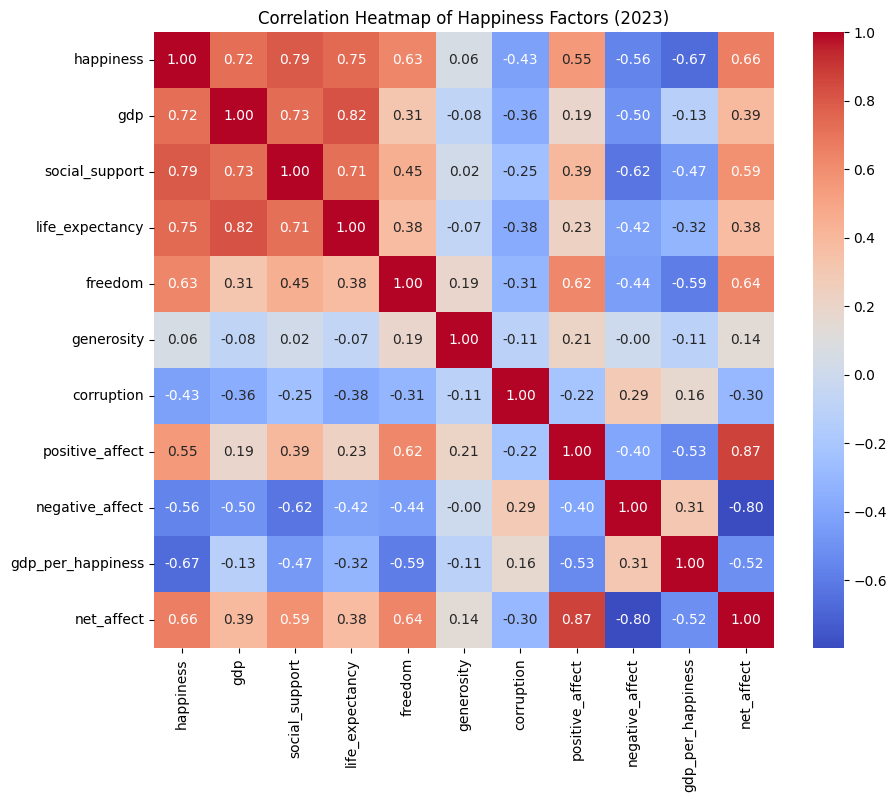

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

numeric_df = df_2023.select_dtypes(include='number').drop('year', axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', 
            fmt='.2f', ax=ax)
ax.set_title('Correlation Heatmap of Happiness Factors (2023)')
plt.show()

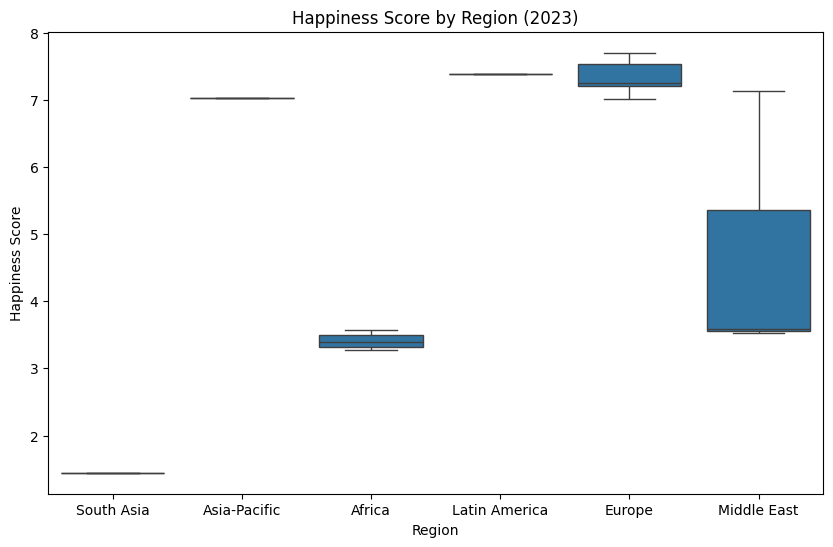

In [28]:
# Simplified region mapping
region_map = {
    'Finland': 'Europe', 'Denmark': 'Europe', 'Iceland': 'Europe',
    'Norway': 'Europe', 'Sweden': 'Europe', 'Netherlands': 'Europe',
    'Luxembourg': 'Europe', 'Australia': 'Asia-Pacific',
    'Kuwait': 'Middle East', 'Costa Rica': 'Latin America',
    'Afghanistan': 'South Asia', 'Lebanon': 'Middle East',
    'Zimbabwe': 'Africa', 'Malawi': 'Africa', 'Yemen': 'Middle East',
    'Sierra Leone': 'Africa', 'Botswana': 'Africa'
}

df_2023 = df_2023.copy()
df_2023['region'] = df_2023['country'].map(region_map)

# Drop countries without a region for now
df_region = df_2023.dropna(subset=['region'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='region', y='happiness', data=df_region, ax=ax)
ax.set_title('Happiness Score by Region (2023)')
ax.set_xlabel('Region')
ax.set_ylabel('Happiness Score')
plt.show()

## Insight 1: GDP influences happiness but doesn't determine it
Countries with the highest GDP do not necessarily have the highest happiness scores. 
Costa Rica, for example, has a modest GDP but ranks in the top 5 happiest countries 
globally, suggesting that wealth alone is not sufficient for happiness.

## Insight 2: Social support is the strongest driver of happiness
Of all factors analysed, social support has the highest correlation with happiness. 
Countries where people feel they have someone to count on in times of trouble 
consistently score higher on the happiness index than wealthy but less socially 
connected nations.

## Insight 3: Generosity has almost no correlation with happiness
Surprisingly, generosity shows nearly zero correlation (0.06) with happiness scores. 
This challenges the common assumption that generous societies are happier societies, 
and suggests happiness may drive generosity rather than the other way around.